<a href="https://colab.research.google.com/github/asianman940121-crypto/-/blob/main/B%E5%B0%8F%E9%A1%8C%E8%BD%89%E5%8C%96%E5%87%BD%E6%95%B8%E8%A9%A6%E4%BD%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(B)請參考 Lecture - Basics of Artificial Neural Networks (類神經網路基礎)P.11 之 8 個不同的轉
化函數(排除 Competitive 之外的所有轉化函數)，將這 8 個不同的轉化函數繪製成二維的圖形，包括
Hard Limit、Symmetrical Hard Limit、Linear、Saturating Linear、Symmetric Saturating Linear、
Log-Sigmoid、Hyperbolic Tangent Sigmoid 以及 Positive Linear 這八種，其中每一張圖形都必須附上
文字說明以及程式碼，不限定使用之程式碼語言，程式碼請自行撰寫(不要使用工具箱)。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#建立橫軸 n，從 -5 到 5，切 1000 個點（讓曲線平滑，同時限制圖片大小）
n = np.linspace(-5, 5, 1000)

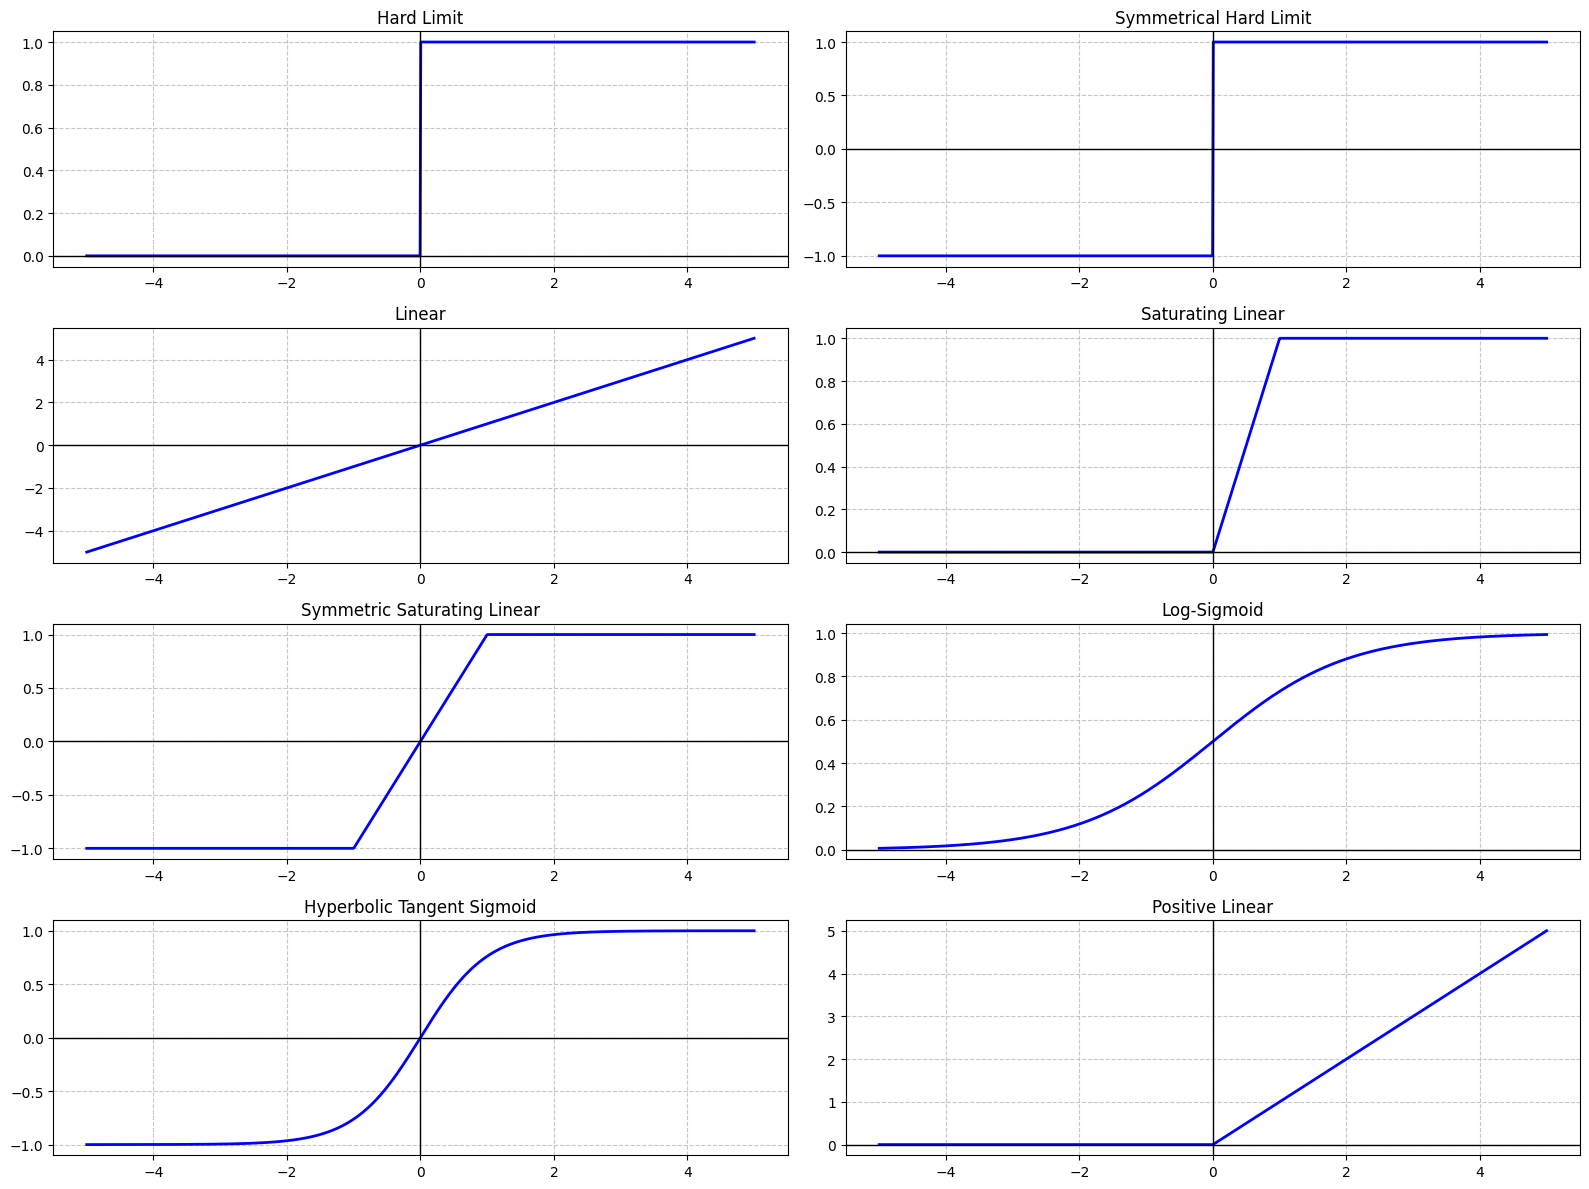

In [ ]:
# 定義輸入向量 n (橫軸範圍)
n = np.linspace(-5, 5, 1000)

# 1. Hard Limit
#常用於分類決策的輸出層，將連續輸入轉化為二進位輸出
#當n<0時a=0，當n>=0時a=1。
a_hardlim = np.where(n < 0, 0, 1)

# 2. Symmetrical Hard Limit
#當n<0時a=-1，當n>=0時，a=1。
#與 Hard Limit 相似，但輸出範圍在-1與1之間，適用於雙極性分類
a_hardlims = np.where(n < 0, -1, 1)

# 3. Linear
#a=n
#線性轉換，通常用於神經網路的線性逼近或輸出層
a_purelin = n

# 4. Saturating Linear
#在[0,1]區間內為線性，小於0則為0，大於1則為1
#結合了線性與硬限制的特質，具備飽和區間
a_satlin = np.piecewise(n, [n < 0, (n >= 0) & (n <= 1), n > 1], [0, lambda n: n, 1])

# 5. Symmetric Saturating Linear
#在[-1,1]區間內為線性，其餘部分則飽和於-1或1
a_satlins = np.piecewise(n, [n < -1, (n >= -1) & (n <= 1), n > 1], [-1, lambda n: n, 1])

# 6. Log-Sigmoid
#a=1/(1+e^-n)
#輸出範圍在(0, 1)之間
a_logsig = 1 / (1 + np.exp(-n))

# 7. Hyperbolic Tangent Sigmoid
#a=(e^n-e^-n)/(e^n+e^-n)
#輸出範圍在(-1, 1)，其數學性質較logsig更具對稱性，有利於模型收斂
a_tansig = (np.exp(n) - np.exp(-n)) / (np.exp(n) + np.exp(-n))

# 8. Positive Linear
#當n<0時a=0；當n>=0時a=n。
#在深度學習中稱為 ReLU，能有效解決梯度消失問題
a_poslin = np.where(n < 0, 0, n)

titles = ['Hard Limit', 'Symmetrical Hard Limit', 'Linear', 'Saturating Linear',
          'Symmetric Saturating Linear', 'Log-Sigmoid', 'Hyperbolic Tangent Sigmoid', 'Positive Linear']
data = [a_hardlim, a_hardlims, a_purelin, a_satlin, a_satlins, a_logsig, a_tansig, a_poslin]

plt.figure(figsize=(16, 12))
for i in range(8):
    plt.subplot(4, 2, i+1)
    plt.plot(n, data[i], 'b', linewidth=2)
    plt.title(titles[i])
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()